For this homework you are going to implement a lane line detector. Lane line detection is crucial for ADAS (Advanced Driver Assistance Systems) systems and, in particular, for LKA (Lane Keep Assist). You will use a picture from a front facing camera (mounted on the car) and will implement the following steps:
- Convert image to gray scale
- Compute edge map
- Apply Hough transform to obtain line parametrizations

In [5]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

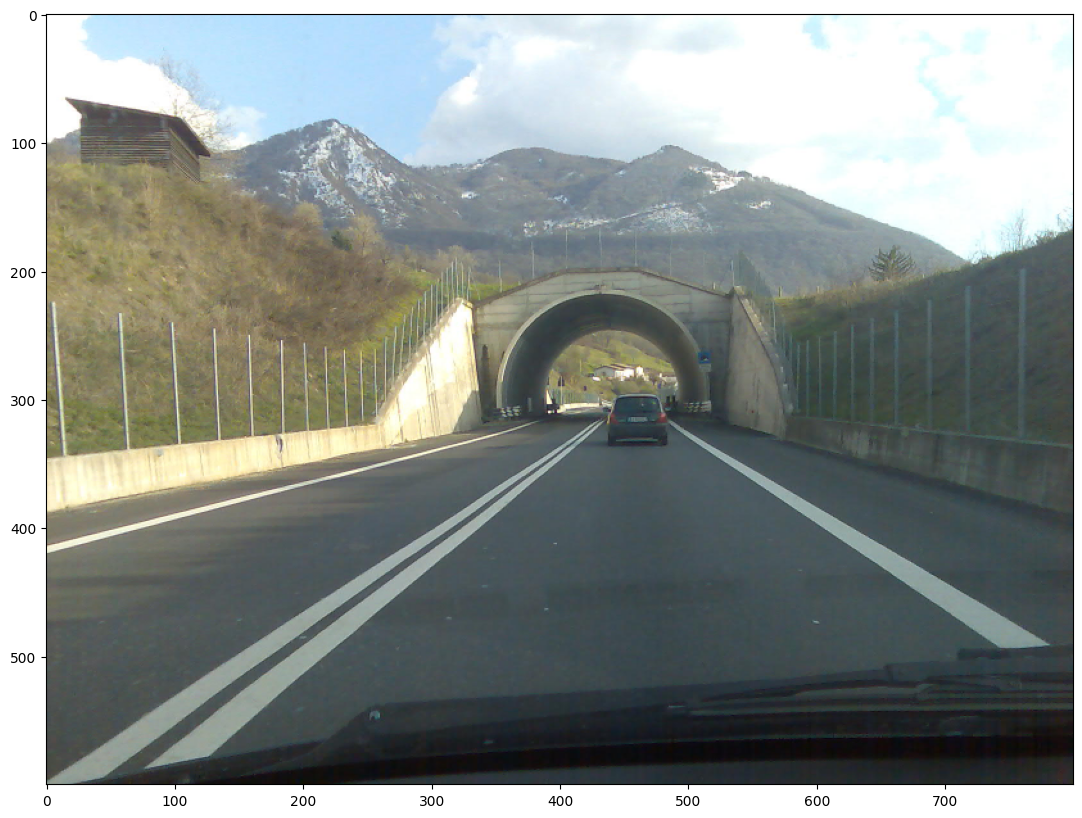

In [6]:
img = cv2.imread('data/dashcam.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, None, fx=0.5, fy=0.5)
plt.imshow(img)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [ 81, 122, 137, ...,  47,  48,  49],
       [128, 141, 140, ...,  48,  49,  49],
       [147, 151, 148, ...,  47,  47,  48]], dtype=uint8)

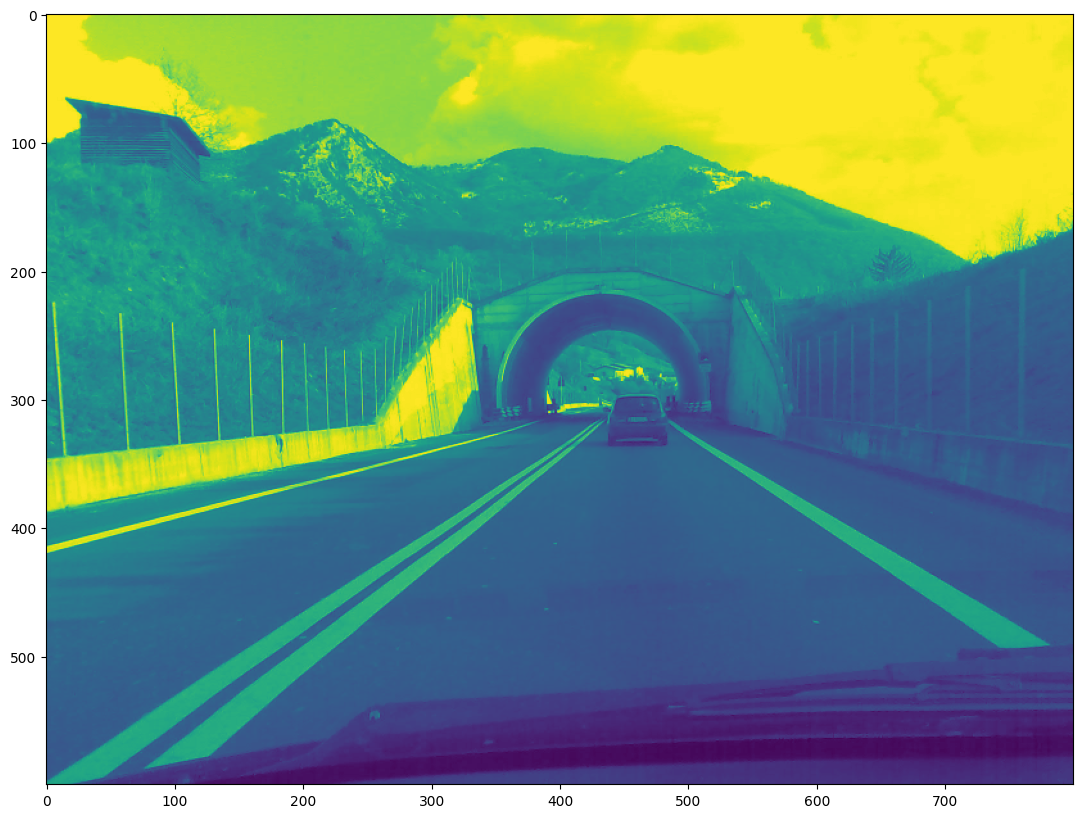

In [9]:
# Convert image to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(gray)
gray

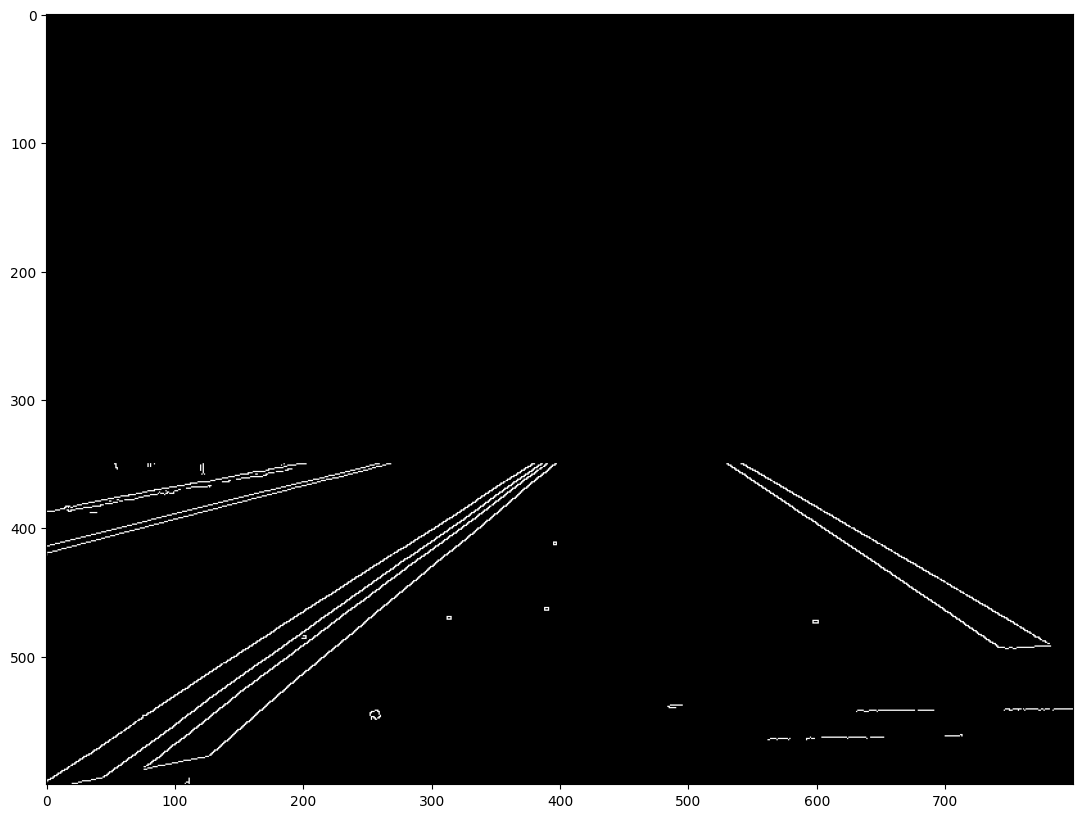

In [11]:
# Obtain edge map
# Hint: you can use Canny edge detector with th_low = 100, th_high = 150
edges = cv2.Canny(gray, threshold1=100, threshold2=150)

# We are only interseted in the road so we will remove everything above the horizon
edges[0:350] = 0
plt.imshow(edges, cmap='gray')

(<Axes: title={'center': 'Edge map'}>,
 Text(0.5, 1.0, 'Edge map'))

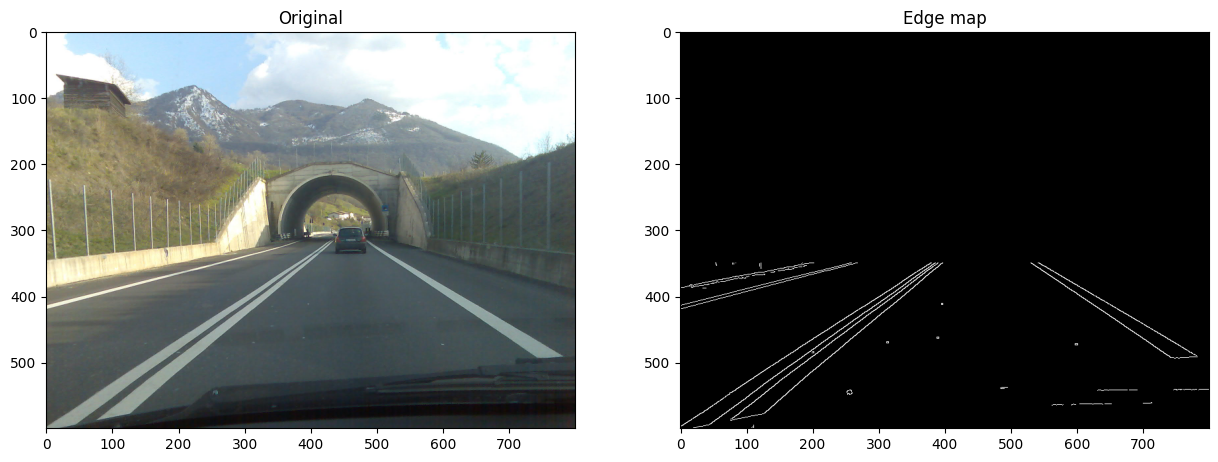

In [13]:
# Let's plot the images
plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(edges, cmap='gray'), plt.title('Edge map')

In [15]:
# Apply Hough transform to parametrize the lines
# Hint 1: Offset resolution of 2 pixels and slope resolution of 2 degrees work well in this case
# Hint 2: A suitable value for the accumulator threshold is 190
lines = cv2.HoughLines(edges, rho=2, theta=2*np.pi/180, threshold=190)

# Let's get rid of the unnecessary dimension
lines = lines[:, 0, :]
lines

array([[521.        ,   0.87266463],
       [505.        ,   0.94247776],
       [509.        ,   0.9075712 ],
       [495.        ,   0.9773844 ],
       [ -7.        ,   2.1642082 ],
       [401.        ,   1.3264502 ],
       [513.        ,   0.94247776],
       [499.        ,   1.012291  ],
       [ 31.        ,   2.0943952 ],
       [511.        ,   0.9773844 ]], dtype=float32)

(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

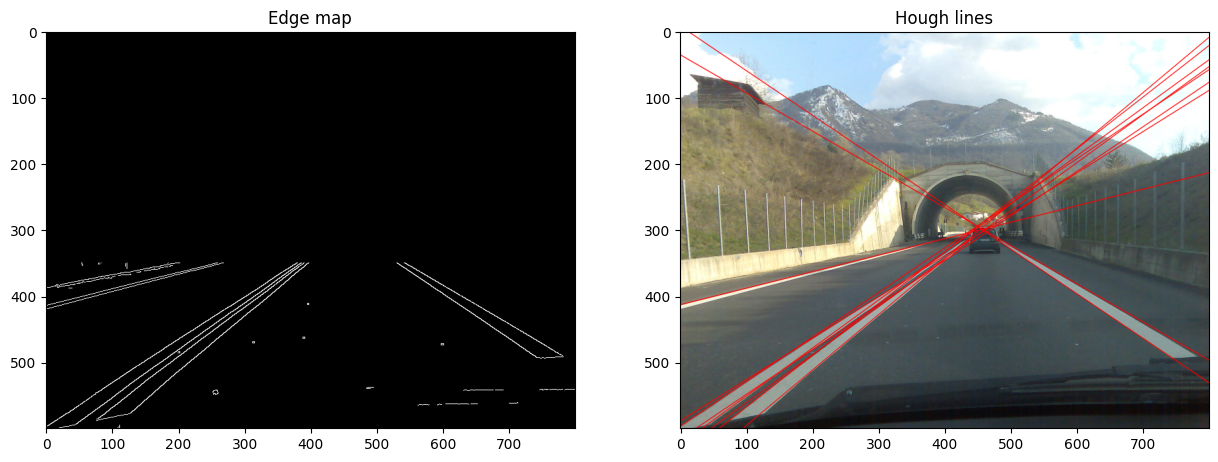

In [17]:
# Plot the resulting Hough lines
result = np.copy(img)
        
if lines is not None:
    for line in lines:
        rho, theta = line
        
        a = math.cos(theta)
        b = math.sin(theta)
        
        x0 = a * rho
        y0 = b * rho
        
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        
        cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

The edge map looks good but the Hough lines are too noisy. Let's clean the Hough lines first by removing all lines that we know cannot represent a lane line. In other words, all lines that are approximately horizontal shall be removed. Remember that horizontal lines correspond to theta = 90 degrees.

In [32]:
# Filter out all lines that are approximately horizontal (+/- 20 degrees). 
filtered_lines = []

angle_thresh = 20 * np.pi / 180  # 20° у радіанах

for line in lines:
    # Extract theta for current line (remember Hough works with radians)
    theta = line[1]
    # Keep line if theta is not horizontal
    if (abs(theta) >= angle_thresh) and (abs(theta - np.pi) >= angle_thresh):
        filtered_lines.append(line)
filtered_lines

[array([521.        ,   0.87266463], dtype=float32),
 array([505.        ,   0.94247776], dtype=float32),
 array([509.       ,   0.9075712], dtype=float32),
 array([495.       ,   0.9773844], dtype=float32),
 array([-7.       ,  2.1642082], dtype=float32),
 array([401.       ,   1.3264502], dtype=float32),
 array([513.        ,   0.94247776], dtype=float32),
 array([499.      ,   1.012291], dtype=float32),
 array([31.       ,  2.0943952], dtype=float32),
 array([511.       ,   0.9773844], dtype=float32)]

(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

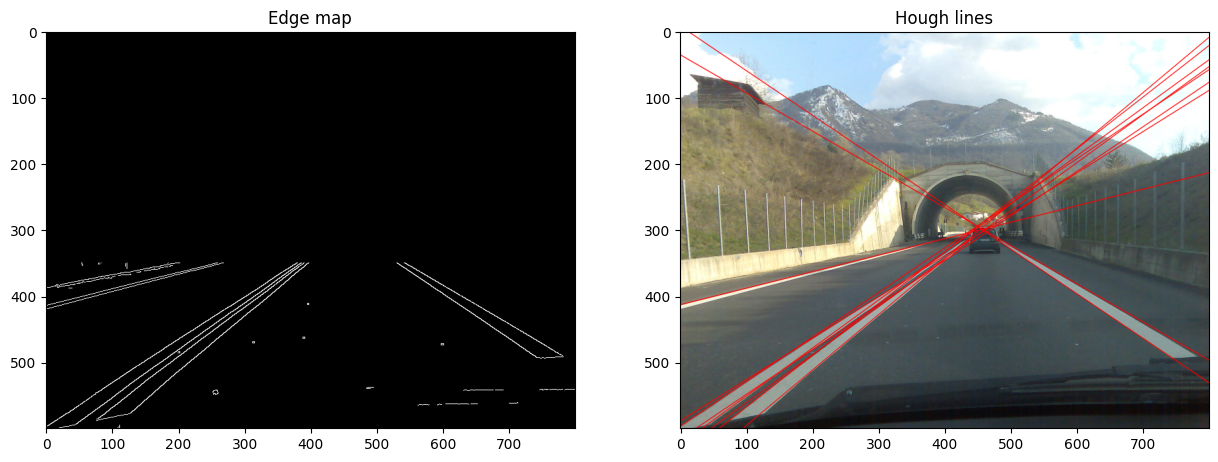

In [34]:
# Let's plot the resulting filtered lines
result = np.copy(img)
 
for line in filtered_lines:
    rho = line[0]
    theta = line[1]
    a = math.cos(theta)
    b = math.sin(theta)
    
    x0 = a * rho
    y0 = b * rho
    
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    
    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

The result is now much better, but still we see some very similar lines. How can we get rid of them?

-Let's apply k-means clustering. It will find the clusters of the 6 we see in the picture lines and use the averages.

In [38]:
# We will apply k-means clustering to refine the detected lines.
# Don't worry, we will learn about the clustering later in the course :-)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6).fit(filtered_lines)
kmeans.cluster_centers_

array([[ 31.        ,   2.09439516],
       [509.5       ,   0.94247778],
       [401.        ,   1.32645023],
       [ -7.        ,   2.16420817],
       [521.        ,   0.87266463],
       [497.        ,   0.99483767]])

(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

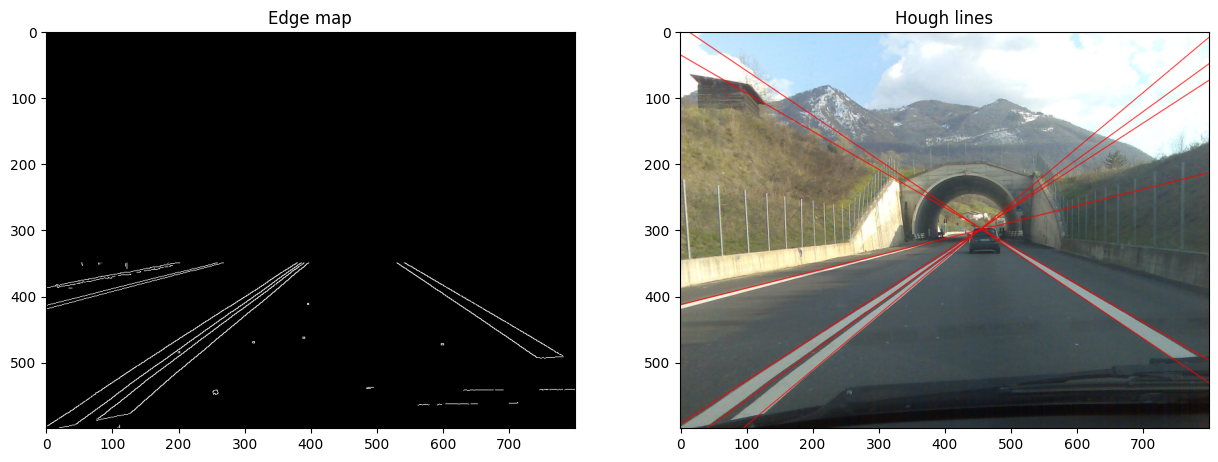

In [40]:
# Again, let's plot the resulting filtered lines
result = np.copy(img)
    
for line in kmeans.cluster_centers_:
    rho = line[0]
    theta = line[1]
    a = math.cos(theta)
    b = math.sin(theta)
    
    x0 = a * rho
    y0 = b * rho
    
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    
    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

Роздільна здатність перетворення Хафа ВАЖЛИВА для отримання хорошого результату, тому що від неї залежить точність знайдених ліній та кількість неправильних результатів.

Поріг акумулятора у перетворенні Хафа теж дуже важливий. Він показує скільки точок визначає певну пряму. Якщо значення порогу мале то виникає багатотліній та як результат це тяжко обробляти. Якщо значення порогу високе то детектяться тільки довгі лінії і можна, як результат, втратити деталі. Тому при виборі значення порогу треба балансувати його.